# Do hub fields keep new concepts? Held-out test (demo)

This notebook is a runnable demo of the experiment **art_wxWssKSUR45f**. The experiment is a sealed, held-out test of two hypotheses about how newly emerging scientific concepts spread across OpenAlex fields:

- **H1 (episode level).** A concept is born in a *home* field and later adopted by another field *j* (one **episode**). Does the adopting field's frozen 1998–2002 **eigenvector gateway centrality** (`gateway_j`) predict whether field *j* **retains** the concept (outcome `R`)? The test asks whether it adds signal beyond a strong baseline `X0`: early volume, growth, off-home share, disciplinary entropy and reach (the B5 block), field size, relatedness `phi(home,j)` and relatedness density, the field's leave-concept-out retention propensity `P_j(-c)`, label coverage, grounding precision and episode size.
- **H3 (concept level).** Does gateway-weighted early landing predict size-adjusted breadth? The concept-level tables behind H3 are not part of this demo; its full-run numbers are in the artifact's `results/h3_results.json`.

**Original pipeline.** `method.py` is the end-to-end orchestrator. It runs about 28 scripts in order: a zero-credit scan of all 2,040 OpenAlex works files (476M works), Aho–Corasick title matching of 56,643 legacy concepts, LLM-benchmarked grounding, frame construction, feature building, a DEV analysis followed by a **FREEZE** of the spec (sha256), one **UNSEAL**, and held-out scoring.

**What this demo runs.** The scan alone needs a 617 MB intermediate store and hours of I/O, so the notebook keeps the orchestrator's code and prints its execution plan. It then runs the two steps that produce the verdict, `dev_freeze` and `heldout` (the code from `models.py`), on a stratified **100-episode subset** of the experiment's final episode table. The subset has 52 DEV episodes from the CS/Eng/BGM/Med groups and 48 held-out episodes from the PHYS/LIFEENV/SOC/MATHDEC groups. The code is the original. With only 100 episodes the numbers are noisy, so the last cell compares them with the full-run results (9,079 DEV and 8,515 held-out episodes). The full run's verdict was **H1 DISCONFIRMED**, with held-out dAUC = −0.00001.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages are needed (joblib ships with scikit-learn).

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original import block of method.py ---
import argparse
import subprocess
import sys
import time

# --- original import block of models.py (the dev_freeze / heldout steps run below) ---
import hashlib
import json
import math
import warnings

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy import stats
from sklearn.metrics import roc_auc_score

# --- additional imports for the notebook (stand-ins for common.py, plotting) ---
import logging
import os
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["datasets"][0]["examples"]), "episodes loaded;", "full-run reference keys:", list(data["metadata"].keys()))

100 episodes loaded; full-run reference keys: ['method_name', 'baseline', 'method', 'H1_dev', 'H1_heldout', 'ladder_dev', 'ladder_heldout', 'gateway_alone_auc']


## Configuration

These are all the tunable parameters, with the original values in the comments. The bootstrap sizes are at the original values: on the 100-episode subset the whole notebook runs in about 1.5 minutes. For a quick smoke test, set B_MAIN = 10 and B_SMALL = 5. `B_MAIN` and `B_SMALL` are the numbers of **concept-clustered refit bootstrap** draws. Each draw resamples concepts within every group, refits both logistic models and recomputes the AUC difference.

In [5]:
B_MAIN = 2000           # bootstrap draws for the primary dAUC CIs          (original: 2000)
B_SMALL = 500           # draws for seed-stability, rival pair and ladder CIs (original: 500)
N_JOBS = 1              # joblib workers                                     (original: 4)
C_REG = 1.0             # inverse L2 strength of the logistic models         (original: 1.0)
MIN_CONCEPTS_EVAL = 5   # held-out group counts as "evaluable" with >= this many concepts (original: 15;
                        # the demo subset holds 12 concepts per held-out group)
RUN_PIPELINE_STEPS = False  # True would launch every pipeline script via subprocess, as method.py does. That needs
                            # the full artifact repository and the OpenAlex snapshot, so the demo only prints the plan.
SEED = 20260928         # global seed (from common.py)

## Shared constants (stand-ins for `common.py`)

`method.py` imports `LOGS, RES, ROOT, SCAN, setup_logger` from `common.py`. The values below are copied from `common.py`. The only changes are that the directories are not created here and `setup_logger` becomes a plain `logging` logger. The group lists are the pre-registered split: development groups CS, Eng, BGM and Med; sealed held-out groups PHYS, LIFEENV, SOC and MATHDEC.

In [6]:
ROOT = Path(".").resolve()
SNAP = ROOT / "snapshot"
SCAN = ROOT / "scan"
RES = ROOT / "results"
LOGS = ROOT / "logs"
FIGS = ROOT / "figures"
DEV_GROUPS = ["CS", "Eng", "BGM", "Med"]
HELD_GROUPS = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
FIELD_NAMES = {11: "Agricultural and Biological Sciences", 12: "Arts and Humanities",
               13: "Biochemistry, Genetics and Molecular Biology", 14: "Business, Management and Accounting",
               15: "Chemical Engineering", 16: "Chemistry", 17: "Computer Science", 18: "Decision Sciences",
               19: "Earth and Planetary Sciences", 20: "Economics, Econometrics and Finance", 21: "Energy",
               22: "Engineering", 23: "Environmental Science", 24: "Immunology and Microbiology",
               25: "Materials Science", 26: "Mathematics", 27: "Medicine", 28: "Neuroscience", 29: "Nursing",
               30: "Pharmacology, Toxicology and Pharmaceutics", 31: "Physics and Astronomy", 32: "Psychology",
               33: "Social Sciences", 34: "Veterinary", 35: "Dentistry", 36: "Health Professions"}


def setup_logger(name: str) -> logging.Logger:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(name)s | %(message)s", stream=sys.stdout,
                        force=True)
    return logging.getLogger(name)


def jdump(obj, path=None):
    return json.dumps(obj, indent=1, default=float)

## The orchestrator (`method.py`)

This is the original step table with the main loop. Each step is `(name, script command, main output)`. A step whose main output already exists is skipped, which makes the pipeline idempotent and resumable. The sequence is:

1. **Lexicon and prescreen**: legacy OpenAlex concepts at levels 2–5, plus Wikidata aliases.
2. **Scan and merge**: one pass over all 2,040 OpenAlex works parquet files.
3. **Onset candidates, backbones and grounding**: a 390-pair LLM benchmark, a sense filter and a per-concept precision gate.
4. **Frame and features**: 12,499 concepts and 27,393 concept × off-home-field episodes.
5. **Tests and checks**: `tests`, `t1`, `t3`.
6. **`dev_freeze`**: runs the DEV analysis, then writes `frozen_spec.json` with its sha256 to `logs/seal.log`.
7. **`unseal`**: can run only once.
8. **`heldout`**: scores the frozen models on the sealed groups.
9. **Replication, report, variants and the independent audits.**

The notebook has one change here: argparse is replaced by function arguments, and `RUN_PIPELINE_STEPS=False` turns the `subprocess.run` calls into a printed plan. The heavy scripts and data are not available in a notebook runtime. The two steps that decide the verdict are run in the cells that follow.

In [7]:
logger = setup_logger("method")
PY = sys.executable
STEPS = [
    ("lexicon", ["lexicon.py"], ROOT / "lexicon_v0.parquet"),
    ("prescreen_sample", ["prescreen.py", "sample"], SCAN / "sample_titles" / "part_001.parquet"),
    ("prescreen_names", ["prescreen.py", "names"], SCAN / "prescreen_survivors.parquet"),
    ("wikidata", ["wikidata_aliases.py"], SCAN / "wikidata_aliases.json"),
    ("prescreen_aliases", ["prescreen.py", "aliases"], ROOT / "lexicon_v1.parquet"),
    ("scan", ["scan_full.py", "--workers", "5"], None),
    ("merge", ["scan_full.py", "--merge"], SCAN / "agg_counts.parquet"),
    ("onset_match", ["frame.py", "match"], RES / "onset_candidates_match.csv"),
    ("backbones", ["backbones.py"], RES / "backbones.json"),
    ("bench", ["grounding.py", "bench"], ROOT / "grounding_benchmark.csv"),
    ("filter", ["grounding.py", "filter"], ROOT / "grounding_report.json"),
    ("onset_grounded", ["frame.py", "grounded"], RES / "onset_candidates_grounded.csv"),
    ("precision", ["grounding.py", "precision"], ROOT / "grounding_precision.csv"),
    ("frame", ["frame.py", "build"], ROOT / "frame_concepts.csv"),
    ("features", ["features.py"], ROOT / "episode_features.csv"),
    ("tests", ["tests/test_units.py"], RES / "unit_tests_T0.json"),
    ("t1", ["checks.py", "t1"], None),
    ("t3", ["checks.py", "t3"], RES / "p78_agreement.csv"),
    ("dev_freeze", ["models.py", "dev"], ROOT / "frozen_spec.json"),
    ("unseal", ["seal.py", "unseal"], ROOT / "sens_episodes_b5_t0p4.csv"),
    ("heldout", ["models.py", "heldout"], RES / "h3_results.json"),
    ("pigeonhole_fix", ["fix_pigeonhole.py"], None),
    ("replicate", ["checks.py", "replicate"], None),
    ("exploratory_domains", ["exploratory_domains.py"], RES / "exploratory_domain_specificity.json"),
    ("report", ["report.py"], ROOT / "method_out.json"),
    ("variants", ["make_variants.py"], ROOT / "preview_method_out.json"),
    ("audit", ["audit.py"], ROOT / "audit.json"),
    ("audit_placebo", ["audit_placebo.py"], RES / "audit_placebo.json"),
]


def main(start=None, only=None) -> None:
    # (notebook: argparse --from / --only replaced by function arguments)
    names = [s[0] for s in STEPS]
    i0 = names.index(start) if start else 0
    for name, cmd, out in STEPS[i0:]:
        if only and name != only:
            continue
        forced = bool(start or only)
        if out is not None and out.exists() and not forced:
            logger.info(f"[skip] {name}: {out.relative_to(ROOT)} exists")
            continue
        if not RUN_PIPELINE_STEPS:  # notebook: print the plan instead of launching the script
            logger.info(f"[plan] {name}: {' '.join(cmd)}")
            continue
        t = time.time()
        logger.info(f"[run ] {name}: {' '.join(cmd)}")
        r = subprocess.run([PY] + cmd, cwd=ROOT)
        if r.returncode != 0:
            logger.error(f"{name} failed with exit code {r.returncode}")
            raise SystemExit(r.returncode)
        logger.info(f"[done] {name} in {time.time()-t:.0f}s")
    if RUN_PIPELINE_STEPS:
        (LOGS / "method_last_run.txt").write_text(time.strftime("%Y-%m-%d %H:%M:%S"))


main()

2026-09-29 11:02:39,446 | method | [plan] lexicon: lexicon.py


2026-09-29 11:02:39,447 | method | [plan] prescreen_sample: prescreen.py sample


2026-09-29 11:02:39,448 | method | [plan] prescreen_names: prescreen.py names


2026-09-29 11:02:39,450 | method | [plan] wikidata: wikidata_aliases.py


2026-09-29 11:02:39,451 | method | [plan] prescreen_aliases: prescreen.py aliases


...

2026-09-29 11:02:39,468 | method | [plan] exploratory_domains: exploratory_domains.py


2026-09-29 11:02:39,470 | method | [plan] report: report.py


2026-09-29 11:02:39,471 | method | [plan] variants: make_variants.py


2026-09-29 11:02:39,472 | method | [plan] audit: audit.py


2026-09-29 11:02:39,473 | method | [plan] audit_placebo: audit_placebo.py


## Models (`models.py`): specification and the L2 logistic model

This cell holds the frozen specification:

- **`X0`** is the 15-covariate baseline.
- **`X1`** is `X0` plus `gateway_j`, the adopting field's eigenvector centrality in the frozen 1998–2002 field backbone.

The primary model is an L2-penalised logistic regression (C = 1). `L2Logit` fits it with exact Newton–IRLS, which reaches the same optimum as sklearn's lbfgs but faster. Covariates are standardised with DEV means and SDs (`std_consts`, `Z`), and missing values become the DEV mean. The code is copied verbatim; only `N_JOBS`, `C_REG`, `B_MAIN` and `B_SMALL` come from the config cell.

In [8]:
logger = setup_logger("models")
X0 = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "log_field_size", "phi_home", "density", "P_j",
      "label_coverage_early", "precision_c", "tag_coverage", "log_n_early", "share_early", "growth_j"]
GATE = "gateway_j"
X1 = X0 + [GATE]
FE_VARY = ["log_field_size", "phi_home", "density", "P_j", "log_n_early", "share_early", "growth_j"]
PJ_M = 5.0      # shrinkage pseudo-count of the leave-concept-out propensity towards the split-set mean
PJ_WIN = 2      # |t0' - t0| <= 2
# (N_JOBS, C_REG, B_MAIN, B_SMALL: set in the config cell)


# ----------------------------------------------------------------------------- helpers
def split_set(s: str) -> str:
    return "HELDOUT" if s.startswith("HELDOUT") else s


def std_consts(df: pd.DataFrame, cols: list[str]) -> dict:
    return {c: [float(df[c].mean()), float(df[c].std() or 1.0)] for c in cols}


def Z(df: pd.DataFrame, cols: list[str], sc: dict) -> np.ndarray:
    X = np.column_stack([(df[c].to_numpy(float) - sc[c][0]) / (sc[c][1] if sc[c][1] > 0 else 1.0) for c in cols])
    return np.nan_to_num(X, nan=0.0)  # NaN -> dev mean (0 after standardisation)


class L2Logit:
    """Exact Newton-IRLS for sklearn's L2 objective 0.5*||w||^2 + C * sum_i s_i * logloss_i (intercept unpenalised).
    Fast for the ~16 standardised covariates used here; converges to the same optimum as lbfgs."""

    def __init__(self, C: float = C_REG):
        self.C = C

    def fit(self, X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> "L2Logit":
        Xa = np.column_stack([np.ones(len(X)), X])
        s = np.ones(len(X)) if w is None else np.asarray(w, float)
        y = np.asarray(y, float)
        P = np.eye(Xa.shape[1])
        P[0, 0] = 0.0
        b = np.zeros(Xa.shape[1])
        for _ in range(100):
            eta = np.clip(Xa @ b, -35, 35)
            p = 1 / (1 + np.exp(-eta))
            g = self.C * Xa.T @ (s * (p - y)) + P @ b
            H = self.C * (Xa * (s * p * (1 - p))[:, None]).T @ Xa + P
            step = np.linalg.solve(H, g)
            b -= step
            if np.abs(step).max() < 1e-10:
                break
        self.coef_, self.intercept_ = b[1:][None, :], np.array([b[0]])
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_[0] + self.intercept_[0]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        p = 1 / (1 + np.exp(-np.clip(self.decision_function(X), -35, 35)))
        return np.column_stack([1 - p, p])


def fit(X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> L2Logit:
    return L2Logit(C_REG).fit(X, y, w)


def auc(y, p, w=None) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return math.nan
    return float(roc_auc_score(y, p, sample_weight=w))

### Evaluation helpers: leave-one-group-out, random-effects pooling, bootstrap CIs

- **`logo_oof`** gives leave-one-home-group-out predictions. The model is trained on three development groups and predicts the fourth, so the DEV dAUC is always measured out of domain.
- **`dl_pool`** is the DerSimonian–Laird random-effects pooling of per-group dAUCs. It reports τ², I² and Q, so a gain confined to one domain shows up as heterogeneity and is not averaged away.
- **`sign_test`** counts how many groups have a positive dAUC.
- **`concept_index`** and **`ci95`** support the bootstrap. Concepts are the resampling unit, so all episodes of a concept move together.

In [9]:
def logo_oof(df: pd.DataFrame, cols: list[str], sc: dict, y: np.ndarray, groups: np.ndarray,
             w: np.ndarray | None = None) -> np.ndarray:
    X = Z(df, cols, sc)
    oof = np.full(len(df), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if len(np.unique(y[tr])) < 2:
            continue
        m = fit(X[tr], y[tr], None if w is None else w[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return oof


def dl_pool(est: list[float], se: list[float]) -> dict:
    y = np.array(est, float)
    v = np.array(se, float) ** 2
    ok = np.isfinite(y) & np.isfinite(v) & (v > 0)
    y, v = y[ok], v[ok]
    k = len(y)
    if k == 0:
        return {"k": 0}
    w = 1 / v
    ybar = (w * y).sum() / w.sum()
    Q = float((w * (y - ybar) ** 2).sum())
    tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    ws = 1 / (v + tau2)
    mu = float((ws * y).sum() / ws.sum())
    se_mu = float(math.sqrt(1 / ws.sum()))
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 and k > 1 else 0.0
    return {"k": k, "pooled": mu, "se": se_mu, "ci95": [mu - 1.96 * se_mu, mu + 1.96 * se_mu], "tau2": tau2,
            "I2": I2, "Q": Q}


def sign_test(vals: list[float]) -> dict:
    v = [x for x in vals if np.isfinite(x)]
    k = sum(1 for x in v if x > 0)
    return {"n": len(v), "n_positive": k, "p_one_sided": float(stats.binomtest(k, len(v), 0.5,
                                                                                alternative="greater").pvalue) if v else math.nan}


def concept_index(df: pd.DataFrame) -> dict:
    return {c: np.nonzero(df.ci.to_numpy() == c)[0] for c in np.unique(df.ci)}


def ci95(a) -> list[float]:
    a = np.asarray([x for x in a if np.isfinite(x)])
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))] if len(a) else [math.nan, math.nan]

### DEV machinery: LOGO refit bootstrap, the dAUC helper and the explanatory ladder

`boot_logo` resamples concepts within each development group and reruns the whole LOGO procedure on every draw. `logo_dauc` returns AUC(X1) − AUC(X0). **`LADDER`** is pre-registered but explanatory only; it plays no part in the verdict. It grows the baseline step by step, from size-only up to the full `X0`, to show where the gateway increment disappears.

In [10]:
# ----------------------------------------------------------------------------- dev: LOGO + refit bootstrap
def _boot_logo(seed: int, df: pd.DataFrame, specs: dict, sc: dict, y: np.ndarray, grp: np.ndarray,
               cidx: dict, cgrp: dict) -> dict:
    rng = np.random.default_rng(seed)
    rows = []
    for g in DEV_GROUPS:
        cs = cgrp[g]
        pick = rng.choice(cs, size=len(cs), replace=True)
        rows.append(np.concatenate([cidx[c] for c in pick]))
    idx = np.concatenate(rows)
    d = df.iloc[idx]
    yy, gg = y[idx], grp[idx]
    out = {}
    for name, cols in specs.items():
        out[name] = logo_oof(d, cols, sc, yy, gg)
    res = {name: auc(yy, p) for name, p in out.items()}
    res["per_group"] = {g: {name: auc(yy[gg == g], out[name][gg == g]) for name in specs} for g in DEV_GROUPS}
    return res


def boot_logo(df, specs, sc, y, grp, B, seed0):
    cidx = concept_index(df)
    cg = df.groupby("ci").group.first()
    cgrp = {g: cg.index[cg == g].to_numpy() for g in DEV_GROUPS}
    return Parallel(n_jobs=N_JOBS, batch_size=8)(delayed(_boot_logo)(seed0 + b, df, specs, sc, y, grp, cidx, cgrp)
                                                 for b in range(B))


def logo_dauc(df, sc, y, grp, gate_col=GATE, base=None) -> dict:
    base = base if base is not None else logo_oof(df, X0, sc, y, grp)
    p1 = logo_oof(df, X0 + [gate_col], sc, y, grp)
    return {"auc0": auc(y, base), "auc1": auc(y, p1), "dauc": auc(y, p1) - auc(y, base), "p0": base, "p1": p1}


B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
# pre-registered explanatory ladder (reported next to the primary, never used for the verdict): where does the
# gateway increment disappear as the baseline grows from the iteration-1 base to the full X0?
LADDER = {"L1_iter1_base": B5 + ["log_n_early", "share_early", "growth_j", "log_field_size"]}
LADDER["L2_plus_relatedness"] = LADDER["L1_iter1_base"] + ["phi_home", "density"]
LADDER["L3_plus_Pj"] = LADDER["L2_plus_relatedness"] + ["P_j"]
LADDER["L4_full_X0"] = X0
LADDER["L0_size_only"] = ["log_n_early", "share_early", "log_field_size"]

### Held-out machinery: frozen fit on all DEV data, one scoring of the sealed groups

`score_heldout` fits `X0` and `X1` once on **all** DEV episodes, then predicts the held-out episodes. The model never sees the held-out fields while it is being selected or tuned. Each bootstrap draw resamples DEV concepts and refits, and separately resamples held-out concepts within each group and evaluates.

In [11]:
# ----------------------------------------------------------------------------- HELD-OUT phase
def _boot_ho(seed, dev, ydev, cidx_dev, dev_cg, ho, yho, cidx_ho, ho_cg, sc, cols_pair):
    rng = np.random.default_rng(seed)
    di = np.concatenate([cidx_dev[c] for g in dev_cg for c in rng.choice(dev_cg[g], len(dev_cg[g]), replace=True)])
    hi_by_g = {g: np.concatenate([cidx_ho[c] for c in rng.choice(ho_cg[g], len(ho_cg[g]), replace=True)])
               for g in ho_cg if len(ho_cg[g])}
    d = dev.iloc[di]
    m0 = fit(Z(d, cols_pair[0], sc), ydev[di])
    m1 = fit(Z(d, cols_pair[1], sc), ydev[di])
    out = {}
    allidx = np.concatenate(list(hi_by_g.values()))
    for key, idx in list(hi_by_g.items()) + [("pooled", allidx)]:
        h = ho.iloc[idx]
        p0 = m0.predict_proba(Z(h, cols_pair[0], sc))[:, 1]
        p1 = m1.predict_proba(Z(h, cols_pair[1], sc))[:, 1]
        out[key] = auc(yho[idx], p1) - auc(yho[idx], p0)
    return out


def score_heldout(dev, ho, sc, cols0=X0, cols1=X1, rcol="R", B=B_MAIN, seed=SEED, groups=HELD_GROUPS):
    """Fit on all dev, evaluate on `ho`. Returns point estimates per group + pooled and bootstrap CIs."""
    ydev = dev[rcol].to_numpy(int)
    yho = ho[rcol].to_numpy(int)
    m0 = fit(Z(dev, cols0, sc), ydev)
    m1 = fit(Z(dev, cols1, sc), ydev)
    p0 = m0.predict_proba(Z(ho, cols0, sc))[:, 1]
    p1 = m1.predict_proba(Z(ho, cols1, sc))[:, 1]
    g = ho.group.to_numpy()
    out = {"n": int(len(ho)), "n_concepts": int(ho.ci.nunique()), "R_rate": float(yho.mean()),
           "auc_X0": auc(yho, p0), "auc_X1": auc(yho, p1), "dauc": auc(yho, p1) - auc(yho, p0), "per_group": {}}
    for gg in groups:
        m = g == gg
        out["per_group"][gg] = {"n": int(m.sum()), "n_concepts": int(ho[m].ci.nunique()),
                                "auc_X0": auc(yho[m], p0[m]), "auc_X1": auc(yho[m], p1[m]),
                                "dauc": auc(yho[m], p1[m]) - auc(yho[m], p0[m]) if m.sum() else math.nan}
    if B:
        cidx_dev = concept_index(dev)
        dcg = dev.groupby("ci").group.first()
        dev_cg = {k: dcg.index[dcg == k].to_numpy() for k in dcg.unique()}
        cidx_ho = concept_index(ho)
        hcg = ho.groupby("ci").group.first()
        ho_cg = {k: hcg.index[hcg == k].to_numpy() for k in groups}
        bs = Parallel(n_jobs=N_JOBS, batch_size=16)(delayed(_boot_ho)(seed + b, dev, ydev, cidx_dev, dev_cg, ho, yho,
                                                                       cidx_ho, ho_cg, sc, (cols0, cols1)) for b in range(B))
        out["boot_ci95"] = ci95([b["pooled"] for b in bs])
        out["boot_p_le0"] = float(np.mean(np.array([b["pooled"] for b in bs]) <= 0))
        for gg in groups:
            vals = [b.get(gg, math.nan) for b in bs]
            out["per_group"][gg]["boot_se"] = float(np.nanstd(vals))
            out["per_group"][gg]["boot_ci95"] = ci95(vals)
    return out, p0, p1

## Load the episode table from the demo data

The original step reads `episode_features.csv`. In this notebook the episode table is rebuilt from `data`, with one row per concept × adopting-field episode. Columns:

- `ci`: the concept. Concepts are the bootstrap cluster unit.
- `field`: the adopting field *j*.
- `home`: the concept's home field (two fields joined by `;` when it has two home fields).
- `t0`: the onset year.
- `group` and `split`: DEV or HELDOUT_*.
- The 16 covariates of `X1`.
- `R`: 1 if field *j* retained the concept.

`P_j`, the leave-concept-out retention propensity, is taken as computed by `add_pj` on the full 27,393-episode frame. It cannot be recomputed from 100 episodes. The full run's frozen predictions are kept too, for comparison at the end.

In [12]:
rows = []
for ex in data["datasets"][0]["examples"]:
    inp = json.loads(ex["input"])
    rows.append({"ci": inp["concept_id"], "concept_id": inp["concept_id"], "name": inp["concept"],
                 "field": inp["adopting_field"], "home": inp["home"], "t0": inp["t0"],
                 "group": inp["group"], "split": inp["split"], **inp["covariates"],
                 "R": float(ex["output"]),
                 "pred_X0_fullrun": float(ex["predict_baseline"]), "pred_X1_fullrun": float(ex["predict_gateway"])})
F = pd.DataFrame(rows)
print(F.groupby(["split"]).agg(episodes=("R", "size"), concepts=("ci", "nunique"), R_rate=("R", "mean")))
F[["name", "field", "home", "t0", "group", "split", "gateway_j", "P_j", "R"]].head(8)

                 episodes  concepts    R_rate
split                                        
DEV                    52        52  0.307692
HELDOUT_LIFEENV        12        12  0.333333
HELDOUT_MATHDEC        12        12  0.333333
HELDOUT_PHYS           12        12  0.333333
HELDOUT_SOC            12        12  0.333333


,name,field,home,t0,group,split,gateway_j,P_j,R
0,CDIO,22,17,2009,CS,DEV,0.24272,0.35732,1.0
1,Matching pursuit,22,17,2005,CS,DEV,0.24272,0.50351,1.0
2,Mean-shift,22,17,2006,CS,DEV,0.24272,0.46230,1.0
3,Cloud computing,27,17,2008,CS,DEV,0.29972,0.47484,1.0
4,Learnability,32,17,2004,CS,DEV,0.07011,0.23203,0.0
5,Privacy policy,22,17;33,2009,CS,DEV,0.24272,0.36170,0.0
6,Cognitive architecture,28,17,2008,CS,DEV,0.17564,0.19952,0.0
7,Pinyin,32,17,2008,CS,DEV,0.07011,0.28253,0.0


## Step `dev_freeze`: DEV analysis (primary LOGO dAUC with a refit bootstrap)

This follows `cmd_dev()` in `models.py`:

1. **Primary.** Compute the out-of-group dAUC = AUC(`X1`) − AUC(`X0`) on DEV, both pooled and per development group.
2. **Refit bootstrap and DL pooling.** Estimate its uncertainty with the concept-clustered refit bootstrap, then pool the per-group dAUCs with DerSimonian–Laird.
3. **T5 seed stability.** Rerun the bootstrap on a disjoint seed range.
4. **Rival head-to-head.** Compare the relatedness pair (`phi_home`, `density`) with gateway on a reduced baseline.
5. **Explanatory ladder** (see the models section).
6. **Gateway-alone AUC.**

The original ran further secondary models here: conditional logit, LPM with field fixed effects, and the boundary interaction. These are omitted because they need statsmodels and multi-episode concepts, which the 100-episode subset lacks. The original step then froze the spec to `frozen_spec.json` and recorded its sha256.

In [13]:
t_start = time.time()
dev = F[F.split == "DEV"].reset_index(drop=True)   # notebook: replaces load_dev() (P_j already attached)
y = dev.R.to_numpy(int)
grp = dev.group.to_numpy()
sc = std_consts(dev, X1)   # original also standardised gateway variants not present in the demo subset
res = {"n_episodes": len(dev), "n_concepts": int(dev.ci.nunique()), "R_rate": float(y.mean()),
       "by_group": dev.groupby("group").agg(n=("R", "size"), R=("R", "mean"), concepts=("ci", "nunique")).to_dict("index")}
logger.info(f"DEV: {res['n_episodes']} episodes / {res['n_concepts']} concepts, R rate {y.mean():.3f}")
base = logo_oof(dev, X0, sc, y, grp)
prim = logo_dauc(dev, sc, y, grp, base=base)
res["primary"] = {"auc_X0": prim["auc0"], "auc_X1": prim["auc1"], "dauc": prim["dauc"],
                  "per_group": {g: {"auc_X0": auc(y[grp == g], prim["p0"][grp == g]),
                                    "auc_X1": auc(y[grp == g], prim["p1"][grp == g]),
                                    "dauc": auc(y[grp == g], prim["p1"][grp == g]) - auc(y[grp == g], prim["p0"][grp == g]),
                                    "n": int((grp == g).sum())} for g in DEV_GROUPS}}
dev["oof_X0"], dev["oof_X1"] = prim["p0"], prim["p1"]
logger.info(f"DEV primary dAUC={prim['dauc']:+.4f} (AUC0 {prim['auc0']:.3f})")
# refit bootstrap (2,000) -- also carries the rival head-to-head models (paired)
Xr = [c for c in X0 if c not in ("phi_home", "density")]
t = time.time()
bs = boot_logo(dev, {"X0": X0, "X1": X1}, sc, y, grp, B_MAIN, SEED)
d_boot = [b["X1"] - b["X0"] for b in bs]
res["primary"]["boot_ci95"] = ci95(d_boot)
res["primary"]["boot_sd"] = float(np.nanstd(d_boot))
res["primary"]["boot_p_le0"] = float(np.mean(np.array(d_boot) <= 0))
for g in DEV_GROUPS:
    gd = [b["per_group"][g]["X1"] - b["per_group"][g]["X0"] for b in bs]
    res["primary"]["per_group"][g]["boot_se"] = float(np.nanstd(gd))
res["primary"]["dl_pool_groups"] = dl_pool([res["primary"]["per_group"][g]["dauc"] for g in DEV_GROUPS],
                                           [res["primary"]["per_group"][g]["boot_se"] for g in DEV_GROUPS])
# T5 stability: second seed on 500 draws vs first 500
bs2 = boot_logo(dev, {"X0": X0, "X1": X1}, sc, y, grp, B_SMALL, SEED + 1_000_000)  # disjoint seed range
c1 = ci95(d_boot[:B_SMALL])
c2 = ci95([b["X1"] - b["X0"] for b in bs2])
res["T5_seed_stability"] = {"ci_seed1_500": c1, "ci_seed2_500": c2, "max_abs_diff": float(np.max(np.abs(np.subtract(c1, c2))))}
logger.info(f"bootstrap done in {time.time()-t:.0f}s; CI {res['primary']['boot_ci95']}")
bsr = boot_logo(dev, {"Xr": Xr, "Xr_rel": Xr + ["phi_home", "density"], "Xr_gw": Xr + [GATE]}, sc, y, grp,
                B_SMALL, SEED + 3)
rel = [b["Xr_rel"] - b["Xr"] for b in bsr]
gw = [b["Xr_gw"] - b["Xr"] for b in bsr]
base_r = logo_oof(dev, Xr, sc, y, grp)
p_rel = logo_oof(dev, Xr + ["phi_home", "density"], sc, y, grp)
p_gw = logo_oof(dev, Xr + [GATE], sc, y, grp)
res["rival_head_to_head"] = {"dauc_relatedness_pair": auc(y, p_rel) - auc(y, base_r),
                             "dauc_gateway": auc(y, p_gw) - auc(y, base_r),
                             "diff_gateway_minus_relatedness": (auc(y, p_gw) - auc(y, p_rel)),
                             "diff_boot_ci95": ci95(np.subtract(gw, rel)),
                             "relatedness_boot_ci95": ci95(rel), "gateway_boot_ci95": ci95(gw)}
# explanatory ladder (dev, LOGO, 500-draw refit bootstrap each)
res["ladder"] = {}
for nm, cols in LADDER.items():
    b0 = logo_oof(dev, cols, sc, y, grp)
    b1 = logo_oof(dev, cols + [GATE], sc, y, grp)
    bl = boot_logo(dev, {"a": cols, "b": cols + [GATE]}, sc, y, grp, B_SMALL, SEED + 5)
    res["ladder"][nm] = {"cols": cols, "auc_base": auc(y, b0), "dauc": auc(y, b1) - auc(y, b0),
                         "ci95": ci95([x["b"] - x["a"] for x in bl])}
res["gateway_alone_auc"] = auc(y, dev[GATE].to_numpy())
res_dev = res
logger.info(f"dev phase done in {time.time()-t_start:.0f}s")
print(json.dumps({k: res_dev["primary"][k] for k in ("auc_X0", "auc_X1", "dauc", "boot_ci95")}, indent=1))

2026-09-29 11:02:39,531 | models | DEV: 52 episodes / 52 concepts, R rate 0.308


2026-09-29 11:02:39,544 | models | DEV primary dAUC=+0.0000 (AUC0 0.882)


2026-09-29 11:02:55,718 | models | bootstrap done in 16s; CI [-0.03547737440795617, 0.023423423423423517]


2026-09-29 11:03:16,074 | models | dev phase done in 37s


{
 "auc_X0": 0.8819444444444444,
 "auc_X1": 0.8819444444444444,
 "dauc": 0.0,
 "boot_ci95": [
  -0.03547737440795617,
  0.023423423423423517
 ]
}


## Step `heldout`: score the frozen models once on the sealed groups

This follows `analyze_heldout()`. The models are fitted on all DEV episodes and evaluated on the PHYS, LIFEENV, SOC and MATHDEC episodes. The step reports:

- the pooled held-out dAUC with its bootstrap CI;
- per-group dAUCs, plus their DL pooling and a sign test across the evaluable groups;
- the relatedness-vs-gateway head-to-head;
- the ladder;
- the gateway-alone AUC.

The 2010–14 cohort, the placebo backbones and the secondary models are omitted. They need data that is not in the demo subset: the cohort episodes and `placebo_gateways.npy`.

In [14]:
F = F[F.R.notna()].copy()  # R undefined when no labelled outcome work exists (share_out = 0/0); excluded as in dev
dev = F[F.split == "DEV"].reset_index(drop=True)
ho = F[F.split.str.startswith("HELDOUT")].reset_index(drop=True)
groups = HELD_GROUPS
res = {"n_dev": len(dev), "n_heldout": len(ho)}
prim, p0, p1 = score_heldout(dev, ho, sc, groups=groups)
ho["pred_X0"], ho["pred_X1"] = p0, p1
res["primary"] = prim
evaluable = [g for g in groups if prim["per_group"][g]["n_concepts"] >= MIN_CONCEPTS_EVAL]  # original: >= 15
res["dl_pool"] = dl_pool([prim["per_group"][g]["dauc"] for g in evaluable],
                         [prim["per_group"][g]["boot_se"] for g in evaluable])
res["evaluable_groups"] = evaluable
res["sign_test_groups"] = sign_test([prim["per_group"][g]["dauc"] for g in evaluable])
logger.info(f"HELD-OUT dAUC={prim['dauc']:+.4f} CI {prim.get('boot_ci95')}")
yho = ho.R.to_numpy(int)
# relatedness head-to-head on held-out (fit on dev)
Xr = [c for c in X0 if c not in ("phi_home", "density")]
rel, _, _ = score_heldout(dev, ho, sc, Xr, Xr + ["phi_home", "density"], B=B_SMALL, seed=SEED + 11, groups=groups)
gw, _, _ = score_heldout(dev, ho, sc, Xr, Xr + [GATE], B=B_SMALL, seed=SEED + 11, groups=groups)
res["rival_head_to_head"] = {"dauc_relatedness_pair": rel["dauc"], "relatedness_ci95": rel.get("boot_ci95"),
                             "dauc_gateway": gw["dauc"], "gateway_ci95": gw.get("boot_ci95"),
                             "diff_gateway_minus_relatedness": gw["dauc"] - rel["dauc"]}
res["ladder"] = {}
for nm, cols in LADDER.items():
    r_, _, _ = score_heldout(dev, ho, sc, cols, cols + [GATE], B=B_SMALL, seed=SEED + 5, groups=groups)
    res["ladder"][nm] = {"auc_base": r_["auc_X0"], "dauc": r_["dauc"], "ci95": r_.get("boot_ci95"),
                         "per_group": {g: v["dauc"] for g, v in r_["per_group"].items()}}
res["gateway_alone_auc"] = auc(yho, ho[GATE].to_numpy())
res_ho = res
print(json.dumps({k: res_ho["primary"][k] for k in ("auc_X0", "auc_X1", "dauc", "boot_ci95")}, indent=1))

2026-09-29 11:03:30,157 | models | HELD-OUT dAUC=+0.0020 CI [-0.03233184842985215, 0.041015625]


{
 "auc_X0": 0.775390625,
 "auc_X1": 0.77734375,
 "dauc": 0.001953125,
 "boot_ci95": [
  -0.03233184842985215,
  0.041015625
 ]
}


## Results: demo subset vs the full run

The tables and figure below set the demo estimates beside the full-run estimates stored in `data["metadata"]`. With only about 12 episodes per group, per-group AUCs swing by several points from one draw to the next, so the demo is **not** expected to reproduce the full-run numbers. Its purpose is to show the procedure end to end.

**How to read the full-run results.**

- **H1 is disconfirmed.** Adding `gateway_j` to `X0` changes the AUC by about 0 on DEV (+0.00001) and on held-out data (−0.00001). The minimum detectable effect is 0.004.
- **The gateway signal is really field propensity.** The ladder shows gateway's DEV gain (+0.0019 over the iteration-1 base) disappearing once `P_j(-c)` enters the baseline.
- **Gateway does not transfer across domains.** On its own it reaches AUC 0.605 on DEV but only 0.506 on held-out groups.
- **Relatedness beats gateway on held-out data.** The relatedness pair adds +0.0034 [0.0010, 0.0051].

In [15]:
M = data["metadata"]
fr_dev, fr_ho = M["H1_dev"], M["H1_heldout"]

summary = pd.DataFrame([
    {"quantity": "DEV LOGO dAUC (X1 - X0)", "demo (100 ep.)": res_dev["primary"]["dauc"], "full run": fr_dev["dauc"]},
    {"quantity": "DEV dAUC 95% CI", "demo (100 ep.)": str(np.round(res_dev["primary"]["boot_ci95"], 4)),
     "full run": str(np.round(fr_dev["ci95"], 4))},
    {"quantity": "Held-out AUC X0", "demo (100 ep.)": res_ho["primary"]["auc_X0"], "full run": fr_ho["auc_X0"]},
    {"quantity": "Held-out AUC X1", "demo (100 ep.)": res_ho["primary"]["auc_X1"], "full run": fr_ho["auc_X1"]},
    {"quantity": "Held-out dAUC (X1 - X0)", "demo (100 ep.)": res_ho["primary"]["dauc"], "full run": fr_ho["dauc"]},
    {"quantity": "Held-out dAUC 95% CI", "demo (100 ep.)": str(np.round(res_ho["primary"]["boot_ci95"], 4)),
     "full run": str(np.round(fr_ho["ci95"], 4))},
    {"quantity": "Held-out DL pooled dAUC", "demo (100 ep.)": res_ho["dl_pool"].get("pooled", math.nan),
     "full run": fr_ho["dl_pool"]["pooled"]},
    {"quantity": "Held-out dAUC relatedness pair", "demo (100 ep.)": res_ho["rival_head_to_head"]["dauc_relatedness_pair"],
     "full run": fr_ho["rival_head_to_head"]["dauc_relatedness_pair"]},
    {"quantity": "Gateway-alone AUC, DEV", "demo (100 ep.)": res_dev["gateway_alone_auc"], "full run": M["gateway_alone_auc"]["dev"]},
    {"quantity": "Gateway-alone AUC, held-out", "demo (100 ep.)": res_ho["gateway_alone_auc"], "full run": M["gateway_alone_auc"]["heldout"]},
])
pd.set_option("display.float_format", lambda v: f"{v:+.5f}")
print("Full-run H1 verdict:", fr_ho["verdict"]["verdict"])
display(summary)

per_group = pd.DataFrame(
    [{"group": g, "split": "DEV", "demo dAUC": res_dev["primary"]["per_group"][g]["dauc"],
      "full-run dAUC": fr_dev["per_group"][g]} for g in DEV_GROUPS] +
    [{"group": g, "split": "HELDOUT", "demo dAUC": res_ho["primary"]["per_group"][g]["dauc"],
      "full-run dAUC": fr_ho["per_group"][g]} for g in HELD_GROUPS])
display(per_group)

ladder = pd.DataFrame({"demo DEV": {k: v["dauc"] for k, v in res_dev["ladder"].items()},
                       "full DEV": M["ladder_dev"],
                       "demo held-out": {k: v["dauc"] for k, v in res_ho["ladder"].items()},
                       "full held-out": M["ladder_heldout"]}).loc[
    ["L0_size_only", "L1_iter1_base", "L2_plus_relatedness", "L3_plus_Pj", "L4_full_X0"]]
display(ladder)
pd.reset_option("display.float_format")

Full-run H1 verdict: DISCONFIRMED


,quantity,demo (100 ep.),full run
0,DEV LOGO dAUC (X1 - X0),+0.00000,+0.00001
1,DEV dAUC 95% CI,[-0.0355 0.0234],[-0.0007 0.0005]
2,Held-out AUC X0,+0.77539,+0.83726
3,Held-out AUC X1,+0.77734,+0.83726
4,Held-out dAUC (X1 - X0),+0.00195,-0.00001
5,Held-out dAUC 95% CI,[-0.0323 0.041 ],[-0.0006 0.0003]
6,Held-out DL pooled dAUC,+0.00374,-0.00004
7,Held-out dAUC relatedness pair,-0.00391,+0.00336
8,"Gateway-alone AUC, DEV",+0.63021,+0.60544
9,"Gateway-alone AUC, held-out",+0.53320,+0.50569


,group,split,demo dAUC,full-run dAUC
0,CS,DEV,+0.00000,+0.00002
1,Eng,DEV,+0.00000,+0.00009
2,BGM,DEV,+0.00000,+0.00010
3,Med,DEV,-0.02778,-0.00005
4,PHYS,HELDOUT,-0.03125,+0.00050
5,LIFEENV,HELDOUT,+0.03125,-0.00026
6,SOC,HELDOUT,+0.00000,-0.00012
7,MATHDEC,HELDOUT,+0.00000,+0.00052


,demo DEV,full DEV,demo held-out,full held-out
L0_size_only,-0.02431,+0.00422,-0.00781,-0.00171
L1_iter1_base,+0.00174,+0.00195,-0.02734,-0.00162
L2_plus_relatedness,-0.00347,+0.00069,-0.02930,-0.00118
L3_plus_Pj,+0.00521,+0.00003,+0.00977,-0.00004
L4_full_X0,+0.00000,+0.00001,+0.00195,-0.00001


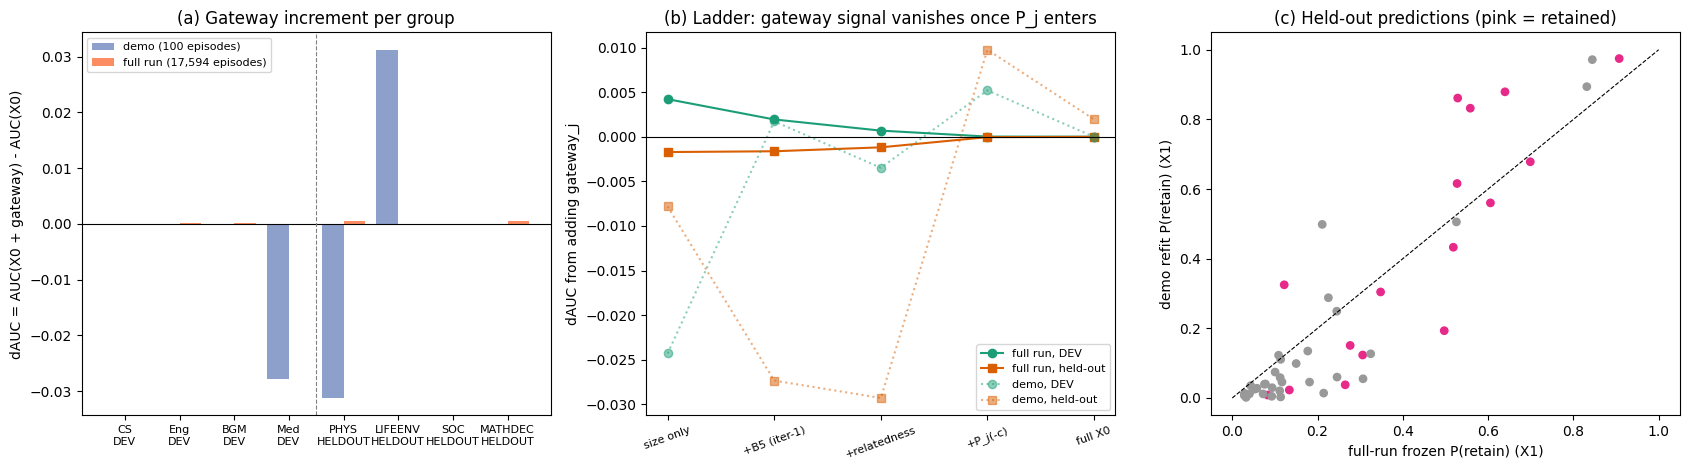

Demo AUC of full-run frozen predictions on these 48 held-out episodes: X0 0.832, X1 0.836


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (a) per-group dAUC: demo vs full run (full-run values are ~0 everywhere)
ax = axes[0]
xs = np.arange(len(per_group))
ax.bar(xs - 0.2, per_group["demo dAUC"], 0.4, label="demo (100 episodes)", color="#8da0cb")
ax.bar(xs + 0.2, per_group["full-run dAUC"], 0.4, label="full run (17,594 episodes)", color="#fc8d62")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(3.5, color="grey", ls="--", lw=0.8)
ax.set_xticks(xs, [f"{g}\n{s}" for g, s in zip(per_group.group, per_group.split)], fontsize=8)
ax.set_ylabel("dAUC = AUC(X0 + gateway) - AUC(X0)")
ax.set_title("(a) Gateway increment per group")
ax.legend(fontsize=8)

# (b) explanatory ladder: gateway increment as the baseline grows (full run)
ax = axes[1]
lx = np.arange(len(ladder))
ax.plot(lx, ladder["full DEV"], "o-", color="#1b9e77", label="full run, DEV")
ax.plot(lx, ladder["full held-out"], "s-", color="#d95f02", label="full run, held-out")
ax.plot(lx, ladder["demo DEV"], "o:", color="#1b9e77", alpha=0.5, label="demo, DEV")
ax.plot(lx, ladder["demo held-out"], "s:", color="#d95f02", alpha=0.5, label="demo, held-out")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(lx, ["size only", "+B5 (iter-1)", "+relatedness", "+P_j(-c)", "full X0"], rotation=20, fontsize=8)
ax.set_ylabel("dAUC from adding gateway_j")
ax.set_title("(b) Ladder: gateway signal vanishes once P_j enters")
ax.legend(fontsize=8)

# (c) held-out predictions: demo refit (X1) vs the full run's frozen model
ax = axes[2]
col = ho.R.map({0: "#999999", 1: "#e7298a"})
ax.scatter(ho.pred_X1_fullrun, ho.pred_X1, c=col, s=28)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("full-run frozen P(retain) (X1)")
ax.set_ylabel("demo refit P(retain) (X1)")
ax.set_title("(c) Held-out predictions (pink = retained)")
plt.tight_layout()
plt.show()

print(f"Demo AUC of full-run frozen predictions on these 48 held-out episodes: "
      f"X0 {auc(ho.R, ho.pred_X0_fullrun):.3f}, X1 {auc(ho.R, ho.pred_X1_fullrun):.3f}")